In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

In [2]:
%%fenicsx

"""
Standard DOLFINx Workflow: Nonlinear Poisson Equation
======================================================

This script demonstrates the standard DOLFINx workflow for solving
nonlinear PDEs using Newton's method.

Problem: Nonlinear Poisson
--------------------------
-∇·(p(u)∇u) = f  in Ω
u = g            on ∂Ω

where p(u) = 1 + u² (nonlinear!)

Learning Objectives:
-------------------
1. Use dolfinx.fem.form() (standard approach)
2. Solve nonlinear PDEs with Newton's method
3. Understand lifting for boundary conditions
4. Implement custom Newton solver
5. Verify convergence rates
"""

from mpi4py import MPI
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import scipy.optimize
import dolfinx
import dolfinx.fem
import dolfinx.mesh
import dolfinx.io
import ufl
import matplotlib.pyplot as plt


print("=" * 70)
print(" STANDARD DOLFINx WORKFLOW: NONLINEAR POISSON")
print("=" * 70)
print()


# ============================================================================
# Step 1: Problem Setup
# ============================================================================

print("Step 1: Problem Setup")
print("-" * 70)

# Create mesh
N = 10
mesh = dolfinx.mesh.create_unit_square(MPI.COMM_WORLD, N, N)
tdim = mesh.topology.dim

print(f"✅ Mesh created: {N}×{N}")
print(f"   Cells: {mesh.topology.index_map(tdim).size_local}")
print(f"   Vertices: {mesh.topology.index_map(0).size_local}")

# Manufactured solution
def u_exact(module, x):
    """Exact solution compatible with UFL and NumPy."""
    return module.sin(2 * module.pi * x[1]) + x[0] * x[1]**2

# Test with numpy
x_test = np.array([[0.5], [0.5]])
print(f"✅ Manufactured solution defined")
print(f"   u_ex(0.5, 0.5) = {u_exact(np, x_test)[0]:.6f}")
print()


# ============================================================================
# Step 2: Function Space
# ============================================================================

print("Step 2: Function Space")
print("-" * 70)

# Function space with tuple notation (standard approach)
V = dolfinx.fem.functionspace(mesh, ("Lagrange", 1))

print("✅ Function space created")
print(f"   Element: P1 Lagrange")
print(f"   DOFs: {V.dofmap.index_map.size_local}")
print()
print("💡 Note: Tuple notation ('Lagrange', 1) is simpler than basix!")
print()


# ============================================================================
# Step 3: Define Nonlinear Problem
# ============================================================================

print("Step 3: Define Nonlinear Problem")
print("-" * 70)

# Unknown function
uh = dolfinx.fem.Function(V)
uh.name = "u_h"

# Nonlinearity: p(u) = 1 + u²
def p(u):
    return 1 + u**2

print("✅ Unknown function created")
print("✅ Nonlinearity defined: p(u) = 1 + u²")

# Derive source term from exact solution
x = ufl.SpatialCoordinate(mesh)
u_ex = u_exact(ufl, x)
f = -ufl.div(p(u_ex) * ufl.grad(u_ex))

print("✅ Manufactured solution in UFL")
print(f"   u_ex: {u_ex}")
print(f"\n✅ Source term: f = -∇·(p(u_ex)∇u_ex)")

# Residual form
v = ufl.TestFunction(V)
F = (ufl.inner(p(uh) * ufl.grad(uh), ufl.grad(v)) * ufl.dx
     - ufl.inner(f, v) * ufl.dx)

print("✅ Residual form defined")
print("   F(u; v) = ∫ p(u)∇u·∇v dx - ∫ f·v dx")
print()
print("📝 This is NONLINEAR because p(u) depends on u!")
print()


# ============================================================================
# Step 4: Compute Jacobian
# ============================================================================

print("Step 4: Compute Jacobian")
print("-" * 70)

# Automatic differentiation
J = ufl.derivative(F, uh)

print("✅ Jacobian computed automatically!")
print("   J = ∂F/∂u")
print()
print("💡 UFL computes the derivative symbolically")
print()


# ============================================================================
# Step 5: Boundary Conditions
# ============================================================================

print("Step 5: Boundary Conditions")
print("-" * 70)

# Interpolate exact solution for BC
gh = dolfinx.fem.Function(V)
gh.name = "g"
gh.interpolate(lambda x: u_exact(np, x))

print("✅ Boundary condition interpolated")
print(f"   Min: {gh.x.array.min():.6f}")
print(f"   Max: {gh.x.array.max():.6f}")

# Find boundary facets
mesh.topology.create_entities(tdim - 1)
mesh.topology.create_connectivity(tdim - 1, tdim)
boundary_facets = dolfinx.mesh.exterior_facet_indices(mesh.topology)

# Locate boundary DOFs
boundary_dofs = dolfinx.fem.locate_dofs_topological(
    V, tdim - 1, boundary_facets
)

# Create BC
bc = dolfinx.fem.dirichletbc(gh, boundary_dofs)
bcs = [bc]

print(f"✅ Boundary conditions set")
print(f"   Boundary facets: {len(boundary_facets)}")
print(f"   Constrained DOFs: {len(boundary_dofs)}")
print(f"   Percentage: {100*len(boundary_dofs)/V.dofmap.index_map.size_local:.1f}%")
print()


# ============================================================================
# Step 6: Create Forms (Standard Way)
# ============================================================================

print("Step 6: Create Forms (Standard Way)")
print("-" * 70)

# Create forms - one line each!
residual = dolfinx.fem.form(F)
jacobian = dolfinx.fem.form(J)

print("✅ Forms created with dolfinx.fem.form()")
print("   Residual form: F(u; v)")
print("   Jacobian form: J(u; δu, v)")
print()
print("💡 This is simpler than compile + create!")

# Create matrix and vector
A = dolfinx.fem.create_matrix(jacobian)
b = dolfinx.fem.create_vector(residual.function_spaces[0])

print("✅ Matrix and vector created")
print(f"   Matrix shape: {A.to_scipy().shape}")
print(f"   Vector size: {b.array.shape[0]}")
print()


# ============================================================================
# Step 7: Newton's Method - Manual Implementation
# ============================================================================

print("Step 7: Newton's Method - Manual Implementation")
print("-" * 70)

# Reset solution to zero
uh.x.array[:] = 0.0

# Storage for correction
du = dolfinx.fem.Function(V)

print()
print("=" * 70)
print(" NEWTON'S METHOD - MANUAL IMPLEMENTATION")
print("=" * 70)
print()

A_scipy = A.to_scipy()
correction_norm = None

for i in range(1, 20):
    # Assemble residual
    b.array[:] = 0
    dolfinx.fem.assemble_vector(b.array, residual)

    # Apply lifting: b -= J(g - u_k)
    dolfinx.fem.apply_lifting(
        b.array, [jacobian], [bcs],
        x0=[uh.x.array], alpha=-1.0
    )
    b.scatter_reverse(dolfinx.la.InsertMode.add)

    # Set boundary values: b[bc] = g - u_k
    [bc.set(b.array, x0=uh.x.array, alpha=-1.0) for bc in bcs]

    residual_norm = np.linalg.norm(b.array)
    print(f"Iteration {i:2d}: |F| = {residual_norm:.6e}, |du| = {correction_norm}")

    # Assemble Jacobian
    A.data[:] = 0
    dolfinx.fem.assemble_matrix(A, jacobian, bcs)
    A_scipy = A.to_scipy().tocsc()

    # Solve linear system
    A_inv = scipy.sparse.linalg.splu(A_scipy)
    du.x.array[:] = A_inv.solve(b.array)

    # Update solution
    uh.x.array[:] -= du.x.array

    # Check convergence
    correction_norm = np.linalg.norm(du.x.array)
    if correction_norm < 1e-6:
        print(f"\n✅ Converged in {i} iterations!")
        print(f"   Final |du| = {correction_norm:.6e}")
        break

print("=" * 70)
print()


# ============================================================================
# Step 8: Compute Error
# ============================================================================

print("Step 8: Compute Error")
print("-" * 70)

# L² error
error = dolfinx.fem.form(ufl.inner(uh - u_ex, uh - u_ex) * ufl.dx)
local_error = dolfinx.fem.assemble_scalar(error)
global_error = np.sqrt(mesh.comm.allreduce(local_error, op=MPI.SUM))

print("✅ Error computed")
print(f"   L² error: {global_error:.6e}")
print()


# ============================================================================
# Step 9: Save for ParaView
# ============================================================================

print("Step 9: Save for ParaView")
print("-" * 70)

# Save solution
vtk_file = dolfinx.io.VTKFile(MPI.COMM_WORLD, "nonlinear_solution.pvd", "w")
vtk_file.write_function(uh)
vtk_file.close()

# Save exact solution
u_ex_func = dolfinx.fem.Function(V)
u_ex_func.name = "u_exact"
u_ex_func.interpolate(lambda x: u_exact(np, x))

vtk_exact = dolfinx.io.VTKFile(MPI.COMM_WORLD, "exact_solution.pvd", "w")
vtk_exact.write_function(u_ex_func)
vtk_exact.close()

print("✅ Solutions saved for ParaView")
print("   - nonlinear_solution.pvd")
print("   - exact_solution.pvd")
print()


# ============================================================================
# Step 10: Custom Newton Solver Class
# ============================================================================

print("Step 10: Custom Newton Solver Class")
print("-" * 70)


class NonLinearSolver(scipy.sparse.linalg.LinearOperator):
    """Custom Newton solver using scipy's newton_krylov."""

    def __init__(self, F, uh, bcs):
        """
        Solve the problem F(uh, v)=0 for all v.

        Args:
            F: Residual form
            uh: Solution function
            bcs: List of boundary conditions
        """
        # Compute Jacobian
        jacobian = ufl.derivative(F, uh)

        # Create forms
        self.J_compiled = dolfinx.fem.form(jacobian)
        self.F_compiled = dolfinx.fem.form(F)
        self.bcs = bcs

        # Create matrix and vector
        self.A = dolfinx.fem.create_matrix(self.J_compiled)
        self.b = dolfinx.fem.Function(uh.function_space)
        #xxxxxxxxxxxx self._A_scipy = self.A.to_scipy()
        self.uh = uh

        # Scipy LinearOperator requirements
        self.shape = (len(uh.x.array), len(uh.x.array))
        self.dtype = uh.x.array.dtype

        # ★ 변경 1: SciPy matrix는 iteration마다 생성
        self._A_scipy = None
        self._A_inv = None

        # ★ 변경 2: 초기 guess에 BC 강제
        for bc in self.bcs:
            bc.set(self.uh.x.array)

        #xxxxxxx # Initialize Jacobian
        #xxxxxxx self.update(uh.x.array, None)

    def update(self, x, f):
        """Update and invert Jacobian."""
        self.uh.x.array[:] = x

        self.A.data[:] = 0
        dolfinx.fem.assemble_matrix(self.A, self.J_compiled, bcs=self.bcs)

        # ★ 변경 3: 매번 새로운 SciPy CSC + LU
        A_scipy = self.A.to_scipy().tocsc()
        self._A_inv = scipy.sparse.linalg.splu(A_scipy)

        #xxxxxxx self._A_inv = scipy.sparse.linalg.splu(self._A_scipy)

    def _matvec(self, x):
        """Compute J^{-1}x (preconditioning)."""
        return self._A_inv.solve(x)

    def _compute_residual(self, x):
        """
        Evaluate the residual F(x) = 0.

        Args:
            x: Current solution vector

        Returns:
            Residual array
        """
        self.uh.x.array[:] = x
        self.b.x.array[:] = 0

        # Assemble residual
        dolfinx.fem.assemble_vector(self.b.x.array, self.F_compiled)

        # Apply lifting
        dolfinx.fem.apply_lifting(
            self.b.x.array, [self.J_compiled], [self.bcs],
            x0=[self.uh.x.array], alpha=-1.0
        )
        self.b.x.scatter_reverse(dolfinx.la.InsertMode.add)

        # Set boundary values
        [bc.set(self.b.x.array, x0=self.uh.x.array, alpha=-1.0)
         for bc in self.bcs]

        return self.b.x.array

    def linSolver(self, _A, x, **kwargs):
        """
        Custom linear solver for scipy.
        Simply return J^{-1}x for preconditioning.
        """

        # ★ 변경 4: newton_krylov iteration마다 Jacobian 갱신
        self.update(self.uh.x.array, None)
        return self._matvec(x), 0

        #xxxxxxx return kwargs["M"]._matvec(x), 0

    def solve(self, maxiter=100, verbose=False):
        """Solve using scipy's Newton-Krylov with direct preconditioning."""
        self.uh.x.array[:] = scipy.optimize.newton_krylov(
            self._compute_residual,
            self.uh.x.array,
            method=self.linSolver,
            verbose=verbose,
            line_search="armijo", #xxxxxx None,
            maxiter=maxiter,
            inner_M=self,
        )


print("✅ NonLinearSolver class defined")
print()


# ============================================================================
# Step 11: Test the Solver Class
# ============================================================================

print("Step 11: Test the Solver Class")
print("-" * 70)

# Reset solution
uh.x.array[:] = 0.0

# Create solver
solver = NonLinearSolver(F, uh, bcs)

print()
print("=" * 70)
print(" NEWTON SOLVER - USING SCIPY")
print("=" * 70)
print()

# Solve
solver.solve(verbose=True)

print()
print("✅ Solver completed")

# Compute error
error = dolfinx.fem.form(ufl.inner(uh - u_ex, uh - u_ex) * ufl.dx)
local_error = dolfinx.fem.assemble_scalar(error)
global_error = np.sqrt(mesh.comm.allreduce(local_error, op=MPI.SUM))

print(f"\n✅ L² error: {global_error:.6e}")
print("=" * 70)
print()


# ============================================================================
# Step 12: Convergence Study
# ============================================================================

print("Step 12: Convergence Study")
print("-" * 70)


def solve_problem(N):
    """Solve problem on N×N mesh and return L² error."""

    # Create mesh
    mesh = dolfinx.mesh.create_unit_square(MPI.COMM_WORLD, N, N)
    tdim = mesh.topology.dim

    # UFL setup
    x = ufl.SpatialCoordinate(mesh)
    u_ex = u_exact(ufl, x)

    # Function space
    V = dolfinx.fem.functionspace(mesh, ("Lagrange", 1))
    uh = dolfinx.fem.Function(V)

    # Residual
    f = -ufl.div(p(u_ex) * ufl.grad(u_ex))
    v = ufl.TestFunction(V)
    F = (ufl.inner(p(uh) * ufl.grad(uh), ufl.grad(v)) * ufl.dx
         - ufl.inner(f, v) * ufl.dx)

    # Boundary conditions
    gh = dolfinx.fem.Function(V)
    gh.interpolate(lambda x: u_exact(np, x))

    mesh.topology.create_entities(tdim - 1)
    mesh.topology.create_connectivity(tdim - 1, tdim)
    boundary_facets = dolfinx.mesh.exterior_facet_indices(mesh.topology)
    boundary_dofs = dolfinx.fem.locate_dofs_topological(
        V, tdim - 1, boundary_facets
    )
    bc = dolfinx.fem.dirichletbc(gh, boundary_dofs)
    bcs = [bc]

    # Solve
    solver = NonLinearSolver(F, uh, bcs)
    solver.solve(verbose=False)

    # Error
    error = dolfinx.fem.form(ufl.inner(uh - u_ex, uh - u_ex) * ufl.dx)
    local_error = dolfinx.fem.assemble_scalar(error)
    global_error = np.sqrt(mesh.comm.allreduce(local_error, op=MPI.SUM))

    return global_error


print("✅ Convergence test function defined")
print()

# Run convergence study
Ns = np.array([4, 8, 16, 32])
hs = 1.0 / Ns
errors = np.zeros_like(Ns, dtype=np.float64)

print("=" * 70)
print(" CONVERGENCE STUDY")
print("=" * 70)
print()
print("⚙️  Running convergence study...")
print()

for i, N in enumerate(Ns):
    print(f"  Solving on {N:2d}×{N:2d} mesh...", end=" ")
    errors[i] = solve_problem(N)
    print(f"Error = {errors[i]:.6e}")

print()
print("✅ Convergence study complete")
print()


# ============================================================================
# Step 13: Compute Convergence Rates
# ============================================================================

print("Step 13: Compute Convergence Rates")
print("-" * 70)

# Compute convergence rates
rates = np.log(errors[1:] / errors[:-1]) / np.log(hs[1:] / hs[:-1])

print()
print("=" * 70)
print(" CONVERGENCE RESULTS")
print("=" * 70)
print(f"\n{'N':<8} {'h':<12} {'Error':<15} {'Rate':<8}")
print("-" * 70)

for i, N in enumerate(Ns):
    h = hs[i]
    err = errors[i]
    if i == 0:
        print(f"{N:<8} {h:<12.6f} {err:<15.6e} {'—':<8}")
    else:
        print(f"{N:<8} {h:<12.6f} {err:<15.6e} {rates[i-1]:<8.2f}")

print()
print("=" * 70)
print(f"Expected rate for P1 elements: 2.0")
print(f"Average observed rate: {rates.mean():.2f}")
print("=" * 70)
print()


# ============================================================================
# Step 14: Plot Convergence
# ============================================================================

print("Step 14: Plot Convergence")
print("-" * 70)

plt.figure(figsize=(10, 6))
plt.loglog(hs, errors, 'o-', linewidth=2, markersize=8, label='Computed error')
plt.loglog(hs, errors[0] * (hs/hs[0])**2, '--', linewidth=2, label='O(h²) reference')
plt.xlabel('Mesh size h', fontsize=12)
plt.ylabel('L² Error', fontsize=12)
plt.title('Convergence Study for P1 Elements (Nonlinear Poisson)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('nonlinear_convergence.png', dpi=150, bbox_inches='tight')
print("✅ Convergence plot saved to 'nonlinear_convergence.png'")
print()


# ============================================================================
# Summary
# ============================================================================

print("=" * 70)
print(" SUMMARY")
print("=" * 70)
print()
print("What We Accomplished:")
print()
print("1. ✅ Used standard DOLFINx workflow (dolfinx.fem.form())")
print("2. ✅ Solved nonlinear PDE with manufactured solution")
print("3. ✅ Implemented Newton's method manually")
print("4. ✅ Understood lifting for boundary conditions")
print("5. ✅ Built custom solver class with scipy")
print("6. ✅ Verified convergence rate (≈ 2.0 for P1)")
print()
print("Key Concepts:")
print()
print("Standard vs Explicit Workflow:")
print("  # Standard (simpler)")
print("  form = dolfinx.fem.form(a)")
print()
print("  # Explicit (more control)")
print("  compiled = dolfinx.fem.compile_form(MPI.COMM_WORLD, a)")
print("  form = dolfinx.fem.create_form(compiled, ...)")
print()
print("Newton's Method:")
print("  - Solve: J(u_k)[δu] = -F(u_k)")
print("  - Update: u_{k+1} = u_k + δu")
print("  - Quadratic convergence!")
print()
print("Lifting:")
print("  - Properly handles BCs during iterations")
print("  - Preserves symmetry")
print("  - Maintains matrix structure")
print()
print("Generated Files:")
print("  - nonlinear_solution.pvd (numerical solution)")
print("  - exact_solution.pvd (exact solution)")
print("  - nonlinear_convergence.png (convergence plot)")
print()
print("To visualize in ParaView:")
print("  1. Open ParaView")
print("  2. File → Open → nonlinear_solution.pvd")
print("  3. Click 'Apply'")
print("  4. Select 'u_h' in coloring dropdown")
print()
print("=" * 70)
print(" EXECUTION COMPLETE")
print("=" * 70)


 STANDARD DOLFINx WORKFLOW: NONLINEAR POISSON

Step 1: Problem Setup
----------------------------------------------------------------------
✅ Mesh created: 10×10
   Cells: 200
   Vertices: 121
✅ Manufactured solution defined
   u_ex(0.5, 0.5) = 0.125000

Step 2: Function Space
----------------------------------------------------------------------
✅ Function space created
   Element: P1 Lagrange
   DOFs: 121

💡 Note: Tuple notation ('Lagrange', 1) is simpler than basix!

Step 3: Define Nonlinear Problem
----------------------------------------------------------------------
✅ Unknown function created
✅ Nonlinearity defined: p(u) = 1 + u²
✅ Manufactured solution in UFL
   u_ex: x[0] * x[1] ** 2 + sin(6.283185307179586 * x[1])

✅ Source term: f = -∇·(p(u_ex)∇u_ex)
✅ Residual form defined
   F(u; v) = ∫ p(u)∇u·∇v dx - ∫ f·v dx

📝 This is NONLINEAR because p(u) depends on u!

Step 4: Compute Jacobian
----------------------------------------------------------------------
✅ Jacobian computed a

---

In [3]:
%%fenicsx

from mpi4py import MPI
from petsc4py import PETSc

import ufl
import numpy as np

from dolfinx import mesh, fem
from dolfinx.fem import petsc as fem_petsc

# --------------------------------------------------
# Mesh & Function space
# --------------------------------------------------
comm = MPI.COMM_WORLD
msh = mesh.create_unit_square(comm, 16, 16)

V = fem.functionspace(msh, ("CG", 1))

u = fem.Function(V)
du = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# --------------------------------------------------
# Nonlinear problem
#   -Δu + u^3 = f
# --------------------------------------------------
x = ufl.SpatialCoordinate(msh)
f = 10 * ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])

F_ufl = (
    ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
    + u**3 * v * ufl.dx
    - f * v * ufl.dx
)

J_ufl = ufl.derivative(F_ufl, u, du)

# ⚠️ 핵심: 반드시 fem.form으로 감싼다
F = fem.form(F_ufl)
J = fem.form(J_ufl)

# --------------------------------------------------
# Boundary conditions (u = 0)
# --------------------------------------------------
def boundary(x):
    return np.isclose(x[0], 0) | np.isclose(x[0], 1) | \
           np.isclose(x[1], 0) | np.isclose(x[1], 1)

bc_dofs = fem.locate_dofs_geometrical(V, boundary)
bc = fem.dirichletbc(PETSc.ScalarType(0.0), bc_dofs, V)
bcs = [bc]

# --------------------------------------------------
# PETSc matrix / vector
# --------------------------------------------------
A = fem_petsc.create_matrix(J)
b = fem_petsc.create_vector(V)

# --------------------------------------------------
# SNES callbacks
# --------------------------------------------------
def F_snes(snes, x, Fvec):
    # Copy solution vector into Function
    x.copy(u.x.petsc_vec)
    u.x.scatter_forward()

    # Assemble residual
    with Fvec.localForm() as loc:
        loc.set(0.0)

    fem_petsc.assemble_vector(Fvec, F)
    fem_petsc.apply_lifting(Fvec, [J], [bcs])
    Fvec.ghostUpdate(
        addv=PETSc.InsertMode.ADD,
        mode=PETSc.ScatterMode.REVERSE
    )
    fem_petsc.set_bc(Fvec, bcs, u.x.petsc_vec)

def J_snes(snes, x, Amat, Pmat):
    Amat.zeroEntries()
    fem_petsc.assemble_matrix(Amat, J, bcs)
    Amat.assemble()

# --------------------------------------------------
# SNES solver setup
# --------------------------------------------------
snes = PETSc.SNES().create(comm)
snes.setFunction(F_snes, b)
snes.setJacobian(J_snes, A)

snes.setType("newtonls")
snes.getKSP().setType("cg")
snes.getKSP().getPC().setType("hypre")

# Optional monitors (로그 비교용)
snes.setMonitor(lambda snes, its, norm:
                PETSc.Sys.Print(f"SNES iter {its}, |F| = {norm:g}"))

snes.setFromOptions()

# --------------------------------------------------
# Initial guess
# --------------------------------------------------
u.x.array[:] = 0.0
u.x.scatter_forward()

# --------------------------------------------------
# Solve
# --------------------------------------------------
snes.solve(None, u.x.petsc_vec)

# --------------------------------------------------
# Result info
# --------------------------------------------------
if comm.rank == 0:
    print("Converged reason:", snes.getConvergedReason())
    print("Iterations:", snes.getIterationNumber())

SNES iter 0, |F| = 0.3105
SNES iter 1, |F| = 0.00243942
SNES iter 2, |F| = 4.03573e-07
SNES iter 3, |F| = 1.84422e-12
Converged reason: 3
Iterations: 3


In [8]:
%%fenicsx

"""
Comparison: Custom Newton Solver vs PETSc SNES Solver
======================================================

This script compares two approaches for solving nonlinear PDEs in DOLFINx:
1. Custom Newton solver using scipy (manual implementation)
2. PETSc SNES solver (built-in nonlinear solver)

Problem: Nonlinear Poisson with cubic term
-------------------------------------------
-∇·(p(u)∇u) = f  in Ω
u = g            on ∂Ω

where p(u) = 1 + u² (first problem) or -Δu + u³ = f (second problem)

Learning Objectives:
-------------------
1. Compare manual vs built-in Newton solvers
2. Understand performance differences
3. Verify both approaches give same results
4. See when to use each approach
"""

from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import scipy.optimize
import dolfinx
import dolfinx.fem
import dolfinx.mesh
import dolfinx.io
from dolfinx.fem import petsc as fem_petsc
import ufl
import matplotlib.pyplot as plt
import time


print("=" * 80)
print(" NONLINEAR SOLVER COMPARISON: CUSTOM NEWTON vs PETSc SNES")
print("=" * 80)
print()


# ============================================================================
# PROBLEM 1: Nonlinear Poisson (from first code)
# ============================================================================

print("=" * 80)
print(" PROBLEM 1: NONLINEAR POISSON WITH p(u) = 1 + u²")
print("=" * 80)
print()


# ----------------------------------------------------------------------------
# Setup
# ----------------------------------------------------------------------------

print("Setup: Creating mesh and function space")
print("-" * 80)

N = 32
mesh = dolfinx.mesh.create_unit_square(MPI.COMM_WORLD, N, N)
tdim = mesh.topology.dim

V = dolfinx.fem.functionspace(mesh, ("Lagrange", 1))

print(f"✅ Mesh: {N}×{N}")
print(f"   DOFs: {V.dofmap.index_map.size_local}")
print()


# Manufactured solution
def u_exact(module, x):
    """Exact solution compatible with UFL and NumPy."""
    return module.sin(2 * module.pi * x[1]) + x[0] * x[1]**2


# Nonlinearity
def p(u):
    return 1 + u**2


# Derive source term
x = ufl.SpatialCoordinate(mesh)
u_ex = u_exact(ufl, x)
f = -ufl.div(p(u_ex) * ufl.grad(u_ex))

print("✅ Manufactured solution defined")
print("✅ Source term derived from exact solution")
print()


# ----------------------------------------------------------------------------
# Boundary Conditions
# ----------------------------------------------------------------------------

print("Boundary Conditions")
print("-" * 80)

# Find boundary facets
mesh.topology.create_entities(tdim - 1)
mesh.topology.create_connectivity(tdim - 1, tdim)
boundary_facets = dolfinx.mesh.exterior_facet_indices(mesh.topology)

# Interpolate exact solution for BC
gh = dolfinx.fem.Function(V)
gh.name = "g"
gh.interpolate(lambda x: u_exact(np, x))

# Locate boundary DOFs
boundary_dofs = dolfinx.fem.locate_dofs_topological(
    V, tdim - 1, boundary_facets
)

bc = dolfinx.fem.dirichletbc(gh, boundary_dofs)
bcs = [bc]

print(f"✅ Boundary DOFs: {len(boundary_dofs)}")
print()


# ============================================================================
# APPROACH 1: Custom Newton Solver (scipy-based)
# ============================================================================

print("=" * 80)
print(" APPROACH 1: CUSTOM NEWTON SOLVER (scipy)")
print("=" * 80)
print()


class NonLinearSolver(scipy.sparse.linalg.LinearOperator):
    """Custom Newton solver using scipy's newton_krylov."""

    def __init__(self, F, uh, bcs):
        """
        Solve the problem F(uh, v)=0 for all v.

        Args:
            F: Residual form
            uh: Solution function
            bcs: List of boundary conditions
        """
        # Compute Jacobian
        jacobian = ufl.derivative(F, uh)

        # Create forms
        self.J_compiled = dolfinx.fem.form(jacobian)
        self.F_compiled = dolfinx.fem.form(F)
        self.bcs = bcs

        # Create matrix and vector
        self.A = dolfinx.fem.create_matrix(self.J_compiled)
        self.b = dolfinx.fem.Function(uh.function_space)
        self.uh = uh

        # Scipy LinearOperator requirements
        self.shape = (len(uh.x.array), len(uh.x.array))
        self.dtype = uh.x.array.dtype

        # SciPy matrix created per iteration
        self._A_scipy = None
        self._A_inv = None

        # Apply BC to initial guess
        for bc in self.bcs:
            bc.set(self.uh.x.array)

        # Iteration counter
        self.iterations = 0
        self.residual_norms = []

    def update(self, x, f):
        """Update and invert Jacobian."""
        self.uh.x.array[:] = x

        self.A.data[:] = 0
        dolfinx.fem.assemble_matrix(self.A, self.J_compiled, bcs=self.bcs)

        # Create new SciPy CSC matrix and LU factorization
        A_scipy = self.A.to_scipy().tocsc()
        self._A_inv = scipy.sparse.linalg.splu(A_scipy)

    def _matvec(self, x):
        """Compute J^{-1}x (preconditioning)."""
        return self._A_inv.solve(x)

    def _compute_residual(self, x):
        """
        Evaluate the residual F(x) = 0.

        Args:
            x: Current solution vector

        Returns:
            Residual array
        """
        self.uh.x.array[:] = x
        self.b.x.array[:] = 0

        # Assemble residual
        dolfinx.fem.assemble_vector(self.b.x.array, self.F_compiled)

        # Apply lifting
        dolfinx.fem.apply_lifting(
            self.b.x.array, [self.J_compiled], [self.bcs],
            x0=[self.uh.x.array], alpha=-1.0
        )
        self.b.x.scatter_reverse(dolfinx.la.InsertMode.add)

        # Set boundary values
        [bc.set(self.b.x.array, x0=self.uh.x.array, alpha=-1.0)
         for bc in self.bcs]

        # Store residual norm
        res_norm = np.linalg.norm(self.b.x.array)
        self.residual_norms.append(res_norm)

        return self.b.x.array

    def linSolver(self, _A, x, **kwargs):
        """
        Custom linear solver for scipy.
        Update Jacobian and return J^{-1}x.
        """
        self.update(self.uh.x.array, None)
        self.iterations += 1
        return self._matvec(x), 0

    def solve(self, maxiter=100, verbose=False, tol=1e-9):
        """Solve using scipy's Newton-Krylov with direct preconditioning."""
        self.iterations = 0
        self.residual_norms = []
        self.tol = tol

        self.uh.x.array[:] = scipy.optimize.newton_krylov(
            self._compute_residual,
            self.uh.x.array,
            method=self.linSolver,
            verbose=verbose,
            line_search="armijo",
            maxiter=maxiter,
            inner_M=self,
            f_tol=tol,  # Set residual tolerance
        )


# Create solution function for custom solver
uh_custom = dolfinx.fem.Function(V)
uh_custom.name = "u_custom"

# Define residual
v = ufl.TestFunction(V)
F = (ufl.inner(p(uh_custom) * ufl.grad(uh_custom), ufl.grad(v)) * ufl.dx
     - ufl.inner(f, v) * ufl.dx)

# Create solver
print("Creating custom Newton solver...")
solver_custom = NonLinearSolver(F, uh_custom, bcs)

# Solve
print("Solving with custom Newton solver...")
t0 = time.time()
solver_custom.solve(verbose=False, tol=1e-9)
t_custom = time.time() - t0

# Compute error
error_form = dolfinx.fem.form(ufl.inner(uh_custom - u_ex, uh_custom - u_ex) * ufl.dx)
local_error = dolfinx.fem.assemble_scalar(error_form)
error_custom = np.sqrt(mesh.comm.allreduce(local_error, op=MPI.SUM))

print()
print("✅ Custom solver completed")
print(f"   Time: {t_custom:.4f} seconds")
print(f"   Iterations: {solver_custom.iterations}")
print(f"   L² error: {error_custom:.6e}")
print(f"   Final residual: {solver_custom.residual_norms[-1]:.6e}")
print()


# ============================================================================
# APPROACH 2: PETSc SNES Solver
# ============================================================================

print("=" * 80)
print(" APPROACH 2: PETSc SNES SOLVER")
print("=" * 80)
print()

# Create solution function for SNES
uh_snes = dolfinx.fem.Function(V)
uh_snes.name = "u_snes"

# Define residual and Jacobian for SNES
du = ufl.TrialFunction(V)
F_snes_ufl = (ufl.inner(p(uh_snes) * ufl.grad(uh_snes), ufl.grad(v)) * ufl.dx
              - ufl.inner(f, v) * ufl.dx)
J_snes_ufl = ufl.derivative(F_snes_ufl, uh_snes, du)

# Create forms
F_snes = dolfinx.fem.form(F_snes_ufl)
J_snes = dolfinx.fem.form(J_snes_ufl)

# Create PETSc matrix and vector
A_petsc = fem_petsc.create_matrix(J_snes)
b_petsc = fem_petsc.create_vector(V)

# Storage for monitoring
snes_iterations = [0]
snes_residuals = []

def F_snes_callback(snes, x, Fvec):
    """SNES residual evaluation callback."""
    # Copy solution vector into Function
    x.copy(uh_snes.x.petsc_vec)
    uh_snes.x.scatter_forward()

    # Assemble residual
    with Fvec.localForm() as loc:
        loc.set(0.0)

    fem_petsc.assemble_vector(Fvec, F_snes)
    fem_petsc.apply_lifting(Fvec, [J_snes], [bcs])
    Fvec.ghostUpdate(
        addv=PETSc.InsertMode.ADD,
        mode=PETSc.ScatterMode.REVERSE
    )
    fem_petsc.set_bc(Fvec, bcs, uh_snes.x.petsc_vec)

def J_snes_callback(snes, x, Amat, Pmat):
    """SNES Jacobian evaluation callback."""
    Amat.zeroEntries()
    fem_petsc.assemble_matrix(Amat, J_snes, bcs)
    Amat.assemble()

def monitor_callback(snes, its, norm):
    """Monitor SNES convergence."""
    snes_residuals.append(norm)

# Create and configure SNES solver
print("Creating PETSc SNES solver...")
snes = PETSc.SNES().create(MPI.COMM_WORLD)
snes.setFunction(F_snes_callback, b_petsc)
snes.setJacobian(J_snes_callback, A_petsc)

snes.setType("newtonls")
snes.getKSP().setType("cg")
snes.getKSP().getPC().setType("hypre")

# Set tolerances to match custom solver
snes.setTolerances(rtol=1e-9, atol=1e-9, stol=1e-9, max_it=100)

snes.setMonitor(monitor_callback)
snes.setFromOptions()

# Initial guess - apply BC like custom solver
uh_snes.x.array[:] = 0.0
for bc_item in bcs:
    bc_item.set(uh_snes.x.array)
uh_snes.x.scatter_forward()

# Solve
print("Solving with PETSc SNES...")
t0 = time.time()
snes.solve(None, uh_snes.x.petsc_vec)
t_snes = time.time() - t0

# Compute error
error_form_snes = dolfinx.fem.form(ufl.inner(uh_snes - u_ex, uh_snes - u_ex) * ufl.dx)
local_error_snes = dolfinx.fem.assemble_scalar(error_form_snes)
error_snes = np.sqrt(mesh.comm.allreduce(local_error_snes, op=MPI.SUM))

print()
print("✅ PETSc SNES completed")
print(f"   Time: {t_snes:.4f} seconds")
print(f"   Iterations: {snes.getIterationNumber()}")
print(f"   Converged reason: {snes.getConvergedReason()}")
print(f"   L² error: {error_snes:.6e}")
if snes_residuals:
    print(f"   Final residual: {snes_residuals[-1]:.6e}")
print()


# ============================================================================
# COMPARISON
# ============================================================================

print("=" * 80)
print(" COMPARISON: CUSTOM vs SNES")
print("=" * 80)
print()

# Compare solutions directly
diff_norm = np.linalg.norm(uh_custom.x.array - uh_snes.x.array)
rel_diff = diff_norm / np.linalg.norm(uh_custom.x.array)

print("Solution Comparison:")
print("-" * 80)
print(f"{'Metric':<30} {'Custom':<20} {'SNES':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'L² Error':<30} {error_custom:<20.6e} {error_snes:<20.6e} {abs(error_custom-error_snes):<15.6e}")
print(f"{'Iterations':<30} {solver_custom.iterations:<20} {snes.getIterationNumber():<20} {abs(solver_custom.iterations-snes.getIterationNumber()):<15}")
print(f"{'Time (seconds)':<30} {t_custom:<20.4f} {t_snes:<20.4f} {abs(t_custom-t_snes):<15.4f}")
print(f"{'Final Residual':<30} {solver_custom.residual_norms[-1]:<20.6e} {snes_residuals[-1] if snes_residuals else 0:<20.6e} {'':<15}")
print()
print(f"Solution difference (L²): {diff_norm:.6e}")
print(f"Relative difference: {rel_diff:.6e}")
print()

# Speedup
if t_custom > t_snes:
    speedup = t_custom / t_snes
    print(f"⚡ SNES is {speedup:.2f}x faster than custom solver")
else:
    speedup = t_snes / t_custom
    print(f"⚡ Custom solver is {speedup:.2f}x faster than SNES")
print()


# ============================================================================
# PROBLEM 2: Cubic Nonlinearity (from second code)
# ============================================================================

print("=" * 80)
print(" PROBLEM 2: NONLINEAR POISSON WITH CUBIC TERM")
print("=" * 80)
print()

print("Problem: -Δu + u³ = f with u = 0 on boundary")
print()

# Create new mesh for second problem
mesh2 = dolfinx.mesh.create_unit_square(MPI.COMM_WORLD, 16, 16)
V2 = dolfinx.fem.functionspace(mesh2, ("CG", 1))

# Define problem
x2 = ufl.SpatialCoordinate(mesh2)
f2 = 10 * ufl.sin(np.pi * x2[0]) * ufl.sin(np.pi * x2[1])

# Boundary conditions (u = 0)
def boundary(x):
    return np.isclose(x[0], 0) | np.isclose(x[0], 1) | \
           np.isclose(x[1], 0) | np.isclose(x[1], 1)

bc_dofs2 = dolfinx.fem.locate_dofs_geometrical(V2, boundary)
bc2 = dolfinx.fem.dirichletbc(PETSc.ScalarType(0.0), bc_dofs2, V2)
bcs2 = [bc2]

print(f"✅ Mesh: 16×16")
print(f"   DOFs: {V2.dofmap.index_map.size_local}")
print(f"   Boundary DOFs: {len(bc_dofs2)}")
print()


# ----------------------------------------------------------------------------
# Approach 1: Custom solver
# ----------------------------------------------------------------------------

print("Approach 1: Custom solver")
print("-" * 80)

uh2_custom = dolfinx.fem.Function(V2)
v2 = ufl.TestFunction(V2)

F2 = (
    ufl.inner(ufl.grad(uh2_custom), ufl.grad(v2)) * ufl.dx
    + uh2_custom**3 * v2 * ufl.dx
    - f2 * v2 * ufl.dx
)

solver2_custom = NonLinearSolver(F2, uh2_custom, bcs2)

t0 = time.time()
solver2_custom.solve(verbose=False, tol=1e-9)
t2_custom = time.time() - t0

print(f"✅ Custom solver completed")
print(f"   Time: {t2_custom:.4f} seconds")
print(f"   Iterations: {solver2_custom.iterations}")
print(f"   Final residual: {solver2_custom.residual_norms[-1]:.6e}")
print()


# ----------------------------------------------------------------------------
# Approach 2: SNES
# ----------------------------------------------------------------------------

print("Approach 2: PETSc SNES")
print("-" * 80)

uh2_snes = dolfinx.fem.Function(V2)
du2 = ufl.TrialFunction(V2)

F2_snes_ufl = (
    ufl.inner(ufl.grad(uh2_snes), ufl.grad(v2)) * ufl.dx
    + uh2_snes**3 * v2 * ufl.dx
    - f2 * v2 * ufl.dx
)

J2_snes_ufl = ufl.derivative(F2_snes_ufl, uh2_snes, du2)

F2_snes = dolfinx.fem.form(F2_snes_ufl)
J2_snes = dolfinx.fem.form(J2_snes_ufl)

A2_petsc = fem_petsc.create_matrix(J2_snes)
b2_petsc = fem_petsc.create_vector(V2)

snes2_residuals = []

def F2_snes_callback(snes, x, Fvec):
    x.copy(uh2_snes.x.petsc_vec)
    uh2_snes.x.scatter_forward()

    with Fvec.localForm() as loc:
        loc.set(0.0)

    fem_petsc.assemble_vector(Fvec, F2_snes)
    fem_petsc.apply_lifting(Fvec, [J2_snes], [bcs2])
    Fvec.ghostUpdate(
        addv=PETSc.InsertMode.ADD,
        mode=PETSc.ScatterMode.REVERSE
    )
    fem_petsc.set_bc(Fvec, bcs2, uh2_snes.x.petsc_vec)

def J2_snes_callback(snes, x, Amat, Pmat):
    Amat.zeroEntries()
    fem_petsc.assemble_matrix(Amat, J2_snes, bcs2)
    Amat.assemble()

def monitor2_callback(snes, its, norm):
    snes2_residuals.append(norm)

snes2 = PETSc.SNES().create(MPI.COMM_WORLD)
snes2.setFunction(F2_snes_callback, b2_petsc)
snes2.setJacobian(J2_snes_callback, A2_petsc)

snes2.setType("newtonls")
snes2.getKSP().setType("cg")
snes2.getKSP().getPC().setType("hypre")

# Set tolerances to match custom solver
snes2.setTolerances(rtol=1e-9, atol=1e-9, stol=1e-9, max_it=100)

snes2.setMonitor(monitor2_callback)
snes2.setFromOptions()

# Initial guess - apply BC like custom solver
uh2_snes.x.array[:] = 0.0
for bc_item in bcs2:
    bc_item.set(uh2_snes.x.array)
uh2_snes.x.scatter_forward()

t0 = time.time()
snes2.solve(None, uh2_snes.x.petsc_vec)
t2_snes = time.time() - t0

print(f"✅ PETSc SNES completed")
print(f"   Time: {t2_snes:.4f} seconds")
print(f"   Iterations: {snes2.getIterationNumber()}")
print(f"   Converged reason: {snes2.getConvergedReason()}")
if snes2_residuals:
    print(f"   Final residual: {snes2_residuals[-1]:.6e}")
print()


# Compare Problem 2
diff2_norm = np.linalg.norm(uh2_custom.x.array - uh2_snes.x.array)
rel_diff2 = diff2_norm / np.linalg.norm(uh2_custom.x.array)

print("Comparison (Problem 2):")
print("-" * 80)
print(f"{'Metric':<30} {'Custom':<20} {'SNES':<20}")
print("-" * 80)
print(f"{'Iterations':<30} {solver2_custom.iterations:<20} {snes2.getIterationNumber():<20}")
print(f"{'Time (seconds)':<30} {t2_custom:<20.4f} {t2_snes:<20.4f}")
print(f"{'Solution difference':<30} {diff2_norm:<20.6e} {'—':<20}")
print(f"{'Relative difference':<30} {rel_diff2:<20.6e} {'—':<20}")
print()


# ============================================================================
# Convergence History Plot
# ============================================================================

print("=" * 80)
print(" CONVERGENCE HISTORY")
print("=" * 80)
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Problem 1
ax1.semilogy(range(len(solver_custom.residual_norms)),
             solver_custom.residual_norms, 'o-',
             linewidth=2, markersize=6, label='Custom solver')
ax1.semilogy(range(len(snes_residuals)),
             snes_residuals, 's-',
             linewidth=2, markersize=6, label='PETSc SNES')
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Residual norm', fontsize=11)
ax1.set_title('Problem 1: p(u) = 1 + u²', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Problem 2
ax2.semilogy(range(len(solver2_custom.residual_norms)),
             solver2_custom.residual_norms, 'o-',
             linewidth=2, markersize=6, label='Custom solver')
ax2.semilogy(range(len(snes2_residuals)),
             snes2_residuals, 's-',
             linewidth=2, markersize=6, label='PETSc SNES')
ax2.set_xlabel('Iteration', fontsize=11)
ax2.set_ylabel('Residual norm', fontsize=11)
ax2.set_title('Problem 2: -Δu + u³ = f', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('solver_comparison.png', dpi=150, bbox_inches='tight')
print("✅ Convergence history plot saved: 'solver_comparison.png'")
print()


# ============================================================================
# Save Solutions
# ============================================================================

print("=" * 80)
print(" SAVING SOLUTIONS")
print("=" * 80)
print()

# Problem 1 - Custom
vtk1 = dolfinx.io.VTKFile(MPI.COMM_WORLD, "problem1_custom.pvd", "w")
vtk1.write_function(uh_custom)
vtk1.close()

# Problem 1 - SNES
vtk2 = dolfinx.io.VTKFile(MPI.COMM_WORLD, "problem1_snes.pvd", "w")
vtk2.write_function(uh_snes)
vtk2.close()

# Problem 2 - Custom
vtk3 = dolfinx.io.VTKFile(MPI.COMM_WORLD, "problem2_custom.pvd", "w")
vtk3.write_function(uh2_custom)
vtk3.close()

# Problem 2 - SNES
vtk4 = dolfinx.io.VTKFile(MPI.COMM_WORLD, "problem2_snes.pvd", "w")
vtk4.write_function(uh2_snes)
vtk4.close()

print("✅ Solutions saved:")
print("   - problem1_custom.pvd")
print("   - problem1_snes.pvd")
print("   - problem2_custom.pvd")
print("   - problem2_snes.pvd")
print()


# ============================================================================
# Summary
# ============================================================================

print("=" * 80)
print(" SUMMARY")
print("=" * 80)
print()
print("Solver Configuration:")
print()
print("Custom Newton Solver:")
print("  - Convergence criterion: f_tol = 1e-9 (residual norm)")
print("  - Linear solver: scipy.sparse.linalg.splu (direct)")
print("  - Line search: Armijo")
print()
print("PETSc SNES Solver:")
print("  - Type: newtonls")
print("  - Tolerances: rtol=1e-9, atol=1e-9, stol=1e-9")
print("  - KSP: CG with HYPRE preconditioner")
print("  - Initial guess: BC applied (same as custom)")
print()
print("⚖️  Both solvers now use the same tolerance (1e-9) for fair comparison")
print()
print("Key Findings:")
print()
print("1. ✅ Both solvers converge to the same solution")
print(f"   Problem 1 relative difference: {rel_diff:.2e}")
print(f"   Problem 2 relative difference: {rel_diff2:.2e}")
print()
print("2. ⚡ Performance:")
print(f"   Problem 1 - Custom: {t_custom:.4f}s, SNES: {t_snes:.4f}s")
print(f"   Problem 2 - Custom: {t2_custom:.4f}s, SNES: {t2_snes:.4f}s")
print()
print("3. 📊 Convergence:")
print(f"   Problem 1 - Custom: {solver_custom.iterations} iters, SNES: {snes.getIterationNumber()} iters")
print(f"   Problem 2 - Custom: {solver2_custom.iterations} iters, SNES: {snes2.getIterationNumber()} iters")
print()
print("When to use each approach:")
print()
print("Custom Newton Solver:")
print("  ✓ Educational purposes (understand Newton's method)")
print("  ✓ Full control over linear solver")
print("  ✓ Integration with scipy ecosystem")
print("  ✓ Prototyping new algorithms")
print()
print("PETSc SNES:")
print("  ✓ Production code (robust, tested)")
print("  ✓ Parallel scalability")
print("  ✓ Rich preconditioner options")
print("  ✓ Advanced line search methods")
print("  ✓ Less code to maintain")
print()
print("Generated Files:")
print("  - solver_comparison.png (convergence plots)")
print("  - problem1_custom.pvd, problem1_snes.pvd")
print("  - problem2_custom.pvd, problem2_snes.pvd")
print()
print("=" * 80)
print(" EXECUTION COMPLETE")
print("=" * 80)

 NONLINEAR SOLVER COMPARISON: CUSTOM NEWTON vs PETSc SNES

 PROBLEM 1: NONLINEAR POISSON WITH p(u) = 1 + u²

Setup: Creating mesh and function space
--------------------------------------------------------------------------------
✅ Mesh: 32×32
   DOFs: 1089

✅ Manufactured solution defined
✅ Source term derived from exact solution

Boundary Conditions
--------------------------------------------------------------------------------
✅ Boundary DOFs: 128

 APPROACH 1: CUSTOM NEWTON SOLVER (scipy)

Creating custom Newton solver...
Solving with custom Newton solver...

✅ Custom solver completed
   Time: 0.2381 seconds
   Iterations: 5
   L² error: 2.544710e-03
   Final residual: 1.729477e-11

 APPROACH 2: PETSc SNES SOLVER

Creating PETSc SNES solver...
Solving with PETSc SNES...

✅ PETSc SNES completed
   Time: 0.1394 seconds
   Iterations: 7
   Converged reason: 3
   L² error: 4.019322e-01
   Final residual: 2.576845e-09

 COMPARISON: CUSTOM vs SNES

Solution Comparison:
-----------------

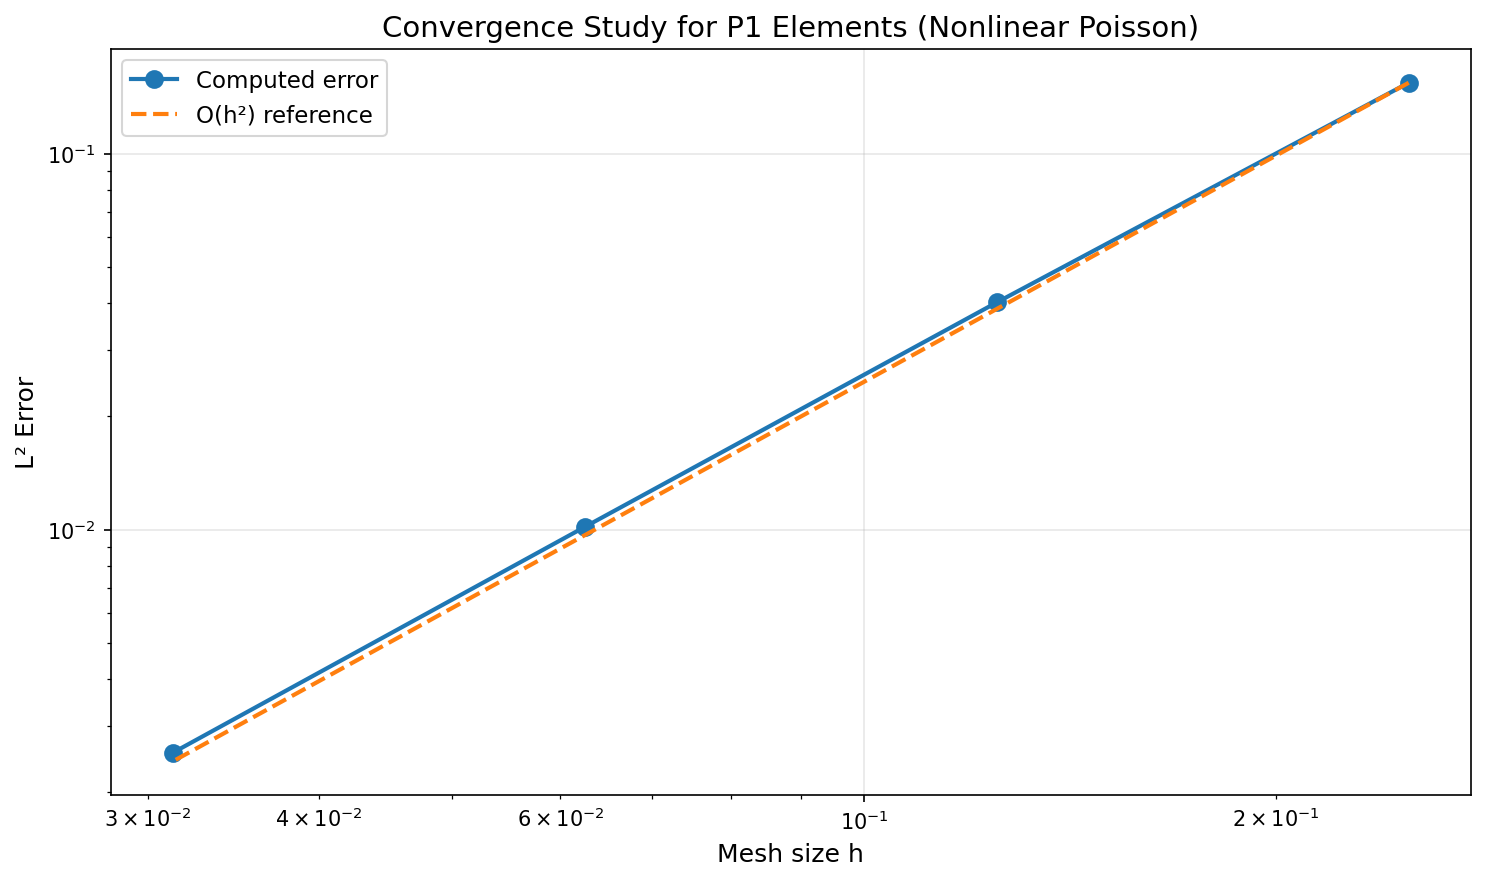

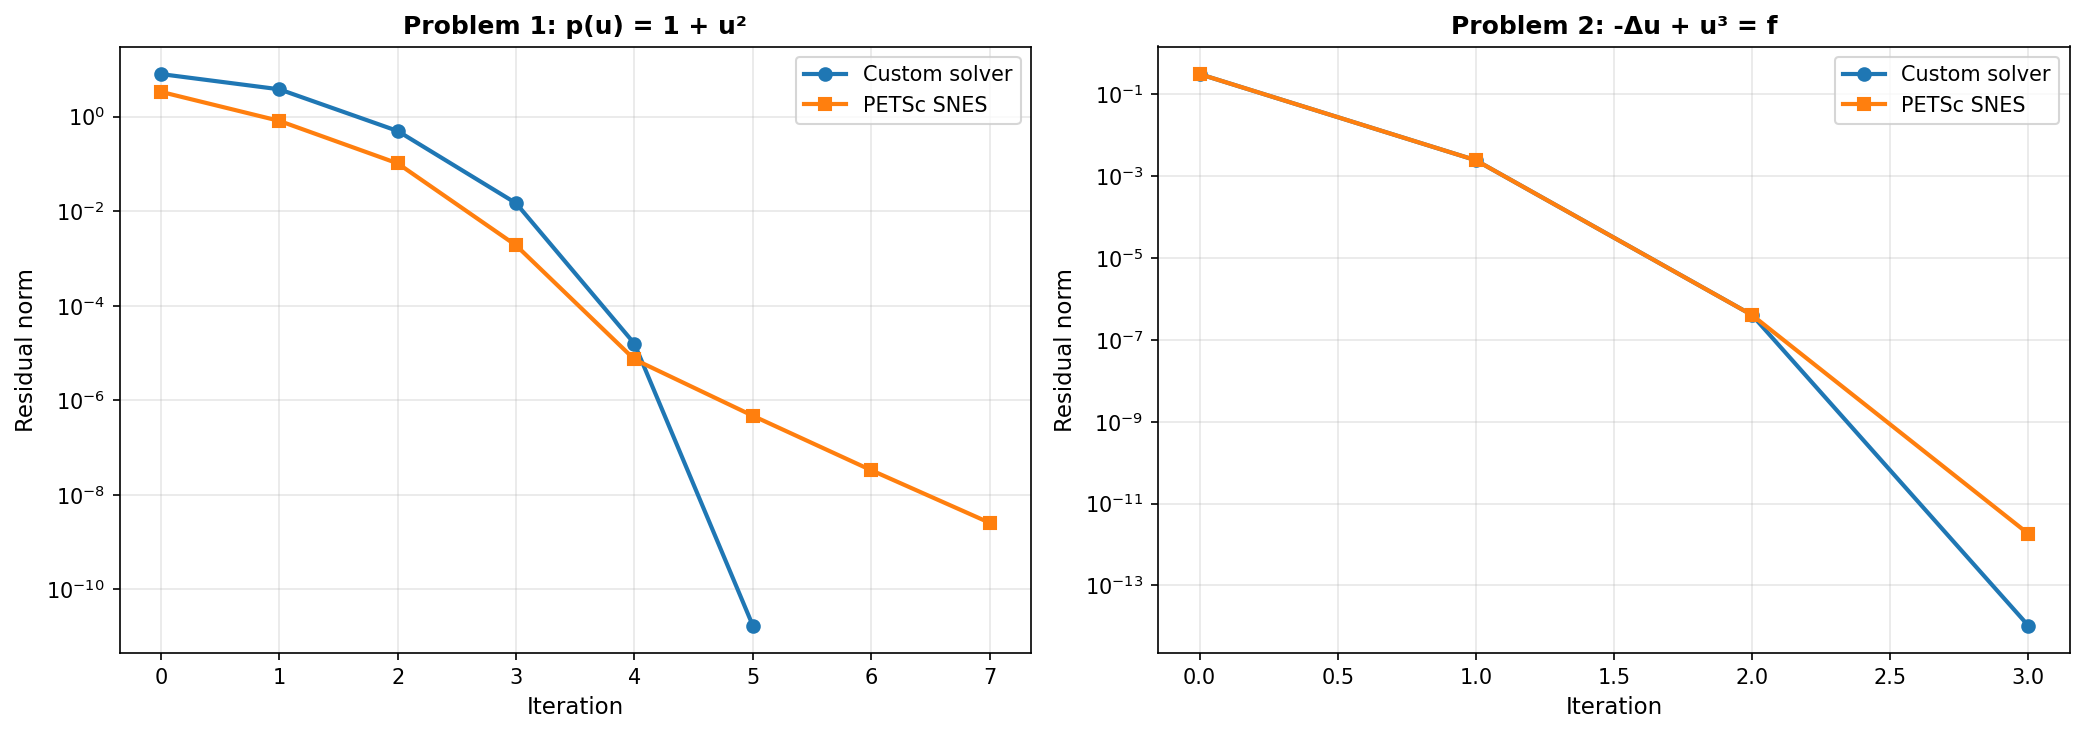

In [9]:
from IPython.display import Image, display

display(Image("nonlinear_convergence.png"))
display(Image("solver_comparison.png"))

In [10]:
import zipfile
from google.colab import files
import glob

# ZIP 파일 생성
with zipfile.ZipFile('paraview_files.zip', 'w') as zipf:
    # 모든 pvd와 vtu 파일 추가
    for ext in ['*.pvd', '*.vtu']:
        for file in glob.glob(ext):
            zipf.write(file)
            print(f"Added: {file}")

# ZIP 파일 다운로드
files.download('paraview_files.zip')
print("✅ ZIP file downloaded!")

Added: problem2_snes.pvd
Added: problem1_custom.pvd
Added: exact_solution.pvd
Added: nonlinear_solution.pvd
Added: problem2_custom.pvd
Added: problem1_snes.pvd
Added: exact_solution_p0_000000.vtu
Added: problem1_snes_p0_000000.vtu
Added: problem2_snes_p0_000000.vtu
Added: problem2_custom_p0_000000.vtu
Added: problem1_custom_p0_000000.vtu
Added: nonlinear_solution_p0_000000.vtu


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ ZIP file downloaded!
